# Voltage Trace Viewer

Plot membrane voltage traces for selected neurons from the combined recording.
Customize the session, neuron indices, and time window below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import glob

## Configuration

Adjust these parameters to select which neurons and time window to plot.

In [2]:
# ============================================================
# CUSTOMIZABLE PARAMETERS
# ============================================================

# Session selection — set to None to use the latest session,
# or specify a timestamp string like "20260223_130621"
SESSION_TIMESTAMP = None

# Which recording to load: "combined" for the merged multi-recording file,
# or an integer (0, 1, 2, ...) for a specific individual recording
RECORDING = "combined"

# Neuron indices to plot — list of integer IDs
# Examples:
#   [0, 1, 2, 3, 4]           — first 5 neurons
#   [10, 50, 100, 200]        — hand-picked neurons
#   list(range(0, 50, 10))    — every 10th neuron from 0-49
NEURON_IDS = [0, 10, 50, 100, 150, 200]

# Time window in milliseconds — (start_ms, end_ms)
# Set to None to plot the full duration
# Examples:
#   (0, 10000)      — first 10 seconds
#   (5000, 15000)   — seconds 5-15
#   (60000, 120000) — second minute (combined recording)
TIME_WINDOW = (0, 10000)

# Plot appearance
FIG_WIDTH = 16        # figure width in inches
TRACE_HEIGHT = 2.0    # height per neuron subplot in inches
SHOW_THRESHOLD = True # draw a dashed line at spike threshold (-50 mV)
SHOW_GRID = True      # show grid lines

## Load Data

In [3]:
DATA_PATH = "LIF data"

# Find available sessions
session_dirs = sorted([
    d for d in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, d))
])

print(f"Available sessions ({len(session_dirs)}):")
for i, sd in enumerate(session_dirs):
    meta_path = os.path.join(DATA_PATH, sd, "session_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
        n_neurons = meta.get('num_neurons', '?')
        n_recs = meta.get('n_recordings', '?')
        dur = meta.get('recording_duration', 0)
        has_combined = os.path.exists(os.path.join(DATA_PATH, sd, "recording_combined.npz"))
        combined_tag = " [has combined]" if has_combined else ""
        print(f"  {i}: {sd} — {n_neurons} neurons, {n_recs} recs x {dur/1000:.0f}s{combined_tag}")

# Select session
if SESSION_TIMESTAMP is None:
    session_name = session_dirs[-1]
    print(f"\nUsing latest session: {session_name}")
else:
    session_name = SESSION_TIMESTAMP
    print(f"\nUsing specified session: {session_name}")

session_dir = os.path.join(DATA_PATH, session_name)
assert os.path.isdir(session_dir), f"Session folder not found: {session_dir}"

Available sessions (5):
  0: 20260223_130621 — 299 neurons, 5 recs x 60s [has combined]
  1: 20260223_151236 — 307 neurons, 5 recs x 60s [has combined]
  2: 20260223_172834 — 294 neurons, 5 recs x 60s [has combined]
  3: 20260223_193040 — 314 neurons, 5 recs x 60s [has combined]
  4: 20260223_215559 — 287 neurons, 5 recs x 60s [has combined]

Using latest session: 20260223_215559


In [4]:
# Load the recording
if RECORDING == "combined":
    rec_path = os.path.join(session_dir, "recording_combined.npz")
    assert os.path.exists(rec_path), (
        f"Combined recording not found at {rec_path}.\n"
        f"Run process_existing_for_gnn.ipynb first, or set RECORDING to an integer."
    )
    print(f"Loading combined recording: {rec_path}")
else:
    rec_path = os.path.join(session_dir, f"recording{int(RECORDING):03d}.npz")
    assert os.path.exists(rec_path), f"Recording not found: {rec_path}"
    print(f"Loading individual recording: {rec_path}")

data = np.load(rec_path, allow_pickle=True)
print(f"Keys: {list(data.keys())}")

# Extract voltage data
assert 'voltage_traces' in data, (
    f"No voltage_traces in this recording. "
    f"Available keys: {list(data.keys())}. "
    f"Voltage recording may have been disabled for this session."
)

voltage_traces = data['voltage_traces']  # (n_neurons, n_samples)
voltage_times = data['voltage_times']     # (n_samples,) in ms
spike_times = data['spike_times']         # (n_neurons,) object array of spike time arrays

n_neurons, n_samples = voltage_traces.shape
total_duration_ms = voltage_times[-1]

print(f"\nNeurons: {n_neurons}")
print(f"Voltage samples: {n_samples}")
print(f"Duration: {total_duration_ms/1000:.1f} s ({total_duration_ms:.0f} ms)")
print(f"Sample rate: {float(data['voltage_sample_rate'])} ms ({1000/float(data['voltage_sample_rate']):.0f} Hz)")

Loading combined recording: LIF data\20260223_215559\recording_combined.npz
Keys: ['spike_times', 'duration_ms', 'n_neurons', 'voltage_traces', 'voltage_times', 'voltage_sample_rate']

Neurons: 287
Voltage samples: 300000
Duration: 300.0 s (299999 ms)
Sample rate: 1.0 ms (1000 Hz)


## Plot Voltage Traces

In [5]:
def plot_voltage_traces(voltage_traces, voltage_times, spike_times,
                        neuron_ids, time_window=None,
                        fig_width=16, trace_height=2.0,
                        show_threshold=True, show_grid=True):
    """
    Plot membrane voltage traces for selected neurons.

    Parameters
    ----------
    voltage_traces : ndarray, shape (n_neurons, n_samples)
    voltage_times  : ndarray, shape (n_samples,) in ms
    spike_times    : object ndarray, shape (n_neurons,), each element is array of spike times in ms
    neuron_ids     : list of int — which neurons to plot
    time_window    : (t_start_ms, t_end_ms) or None for full range
    fig_width      : figure width in inches
    trace_height   : height per subplot in inches
    show_threshold : draw dashed line at -50 mV
    show_grid      : show grid lines
    """
    n_total = voltage_traces.shape[0]

    # Validate neuron IDs
    valid_ids = [nid for nid in neuron_ids if 0 <= nid < n_total]
    if len(valid_ids) < len(neuron_ids):
        invalid = set(neuron_ids) - set(valid_ids)
        print(f"Warning: skipping invalid neuron IDs {invalid} (valid range: 0-{n_total-1})")
    neuron_ids = valid_ids

    if len(neuron_ids) == 0:
        print("No valid neurons to plot.")
        return None

    # Determine time slice
    if time_window is not None:
        t_start, t_end = time_window
        mask = (voltage_times >= t_start) & (voltage_times <= t_end)
        t_slice = voltage_times[mask]
        v_slice = voltage_traces[:, mask]
    else:
        t_slice = voltage_times
        v_slice = voltage_traces
        t_start = voltage_times[0]
        t_end = voltage_times[-1]

    # Create figure
    n_plots = len(neuron_ids)
    fig, axes = plt.subplots(n_plots, 1, figsize=(fig_width, trace_height * n_plots),
                             sharex=True, squeeze=False)
    axes = axes.flatten()

    # Convert time to seconds for x-axis
    t_sec = t_slice / 1000.0

    for i, nid in enumerate(neuron_ids):
        ax = axes[i]
        v = v_slice[nid]

        # Plot voltage trace
        ax.plot(t_sec, v, color='#2060B0', linewidth=0.5, rasterized=True)

        # Mark spike times with red dots
        spk = spike_times[nid]
        if len(spk) > 0:
            spk_in_window = spk[(spk >= t_start) & (spk <= t_end)]
            if len(spk_in_window) > 0:
                ax.plot(spk_in_window / 1000.0,
                        np.full(len(spk_in_window), 25.0),
                        'r|', markersize=6, markeredgewidth=1.0)

        # Threshold line
        if show_threshold:
            ax.axhline(-50, color='red', linestyle='--', linewidth=0.5, alpha=0.4)

        ax.set_ylabel(f'N{nid}\n(mV)', fontsize=9)
        ax.set_ylim(-82, 30)

        if show_grid:
            ax.grid(True, alpha=0.3)

        # Spike count annotation
        spk_count = len(spk[(spk >= t_start) & (spk <= t_end)]) if len(spk) > 0 else 0
        ax.text(0.995, 0.92, f'{spk_count} spikes',
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                color='#666666')

    axes[-1].set_xlabel('Time (s)', fontsize=11)

    window_str = f"{t_start/1000:.1f}–{t_end/1000:.1f} s"
    fig.suptitle(f'Voltage Traces — {window_str} ({n_plots} neurons)', fontsize=13, y=1.01)
    fig.tight_layout()
    return fig

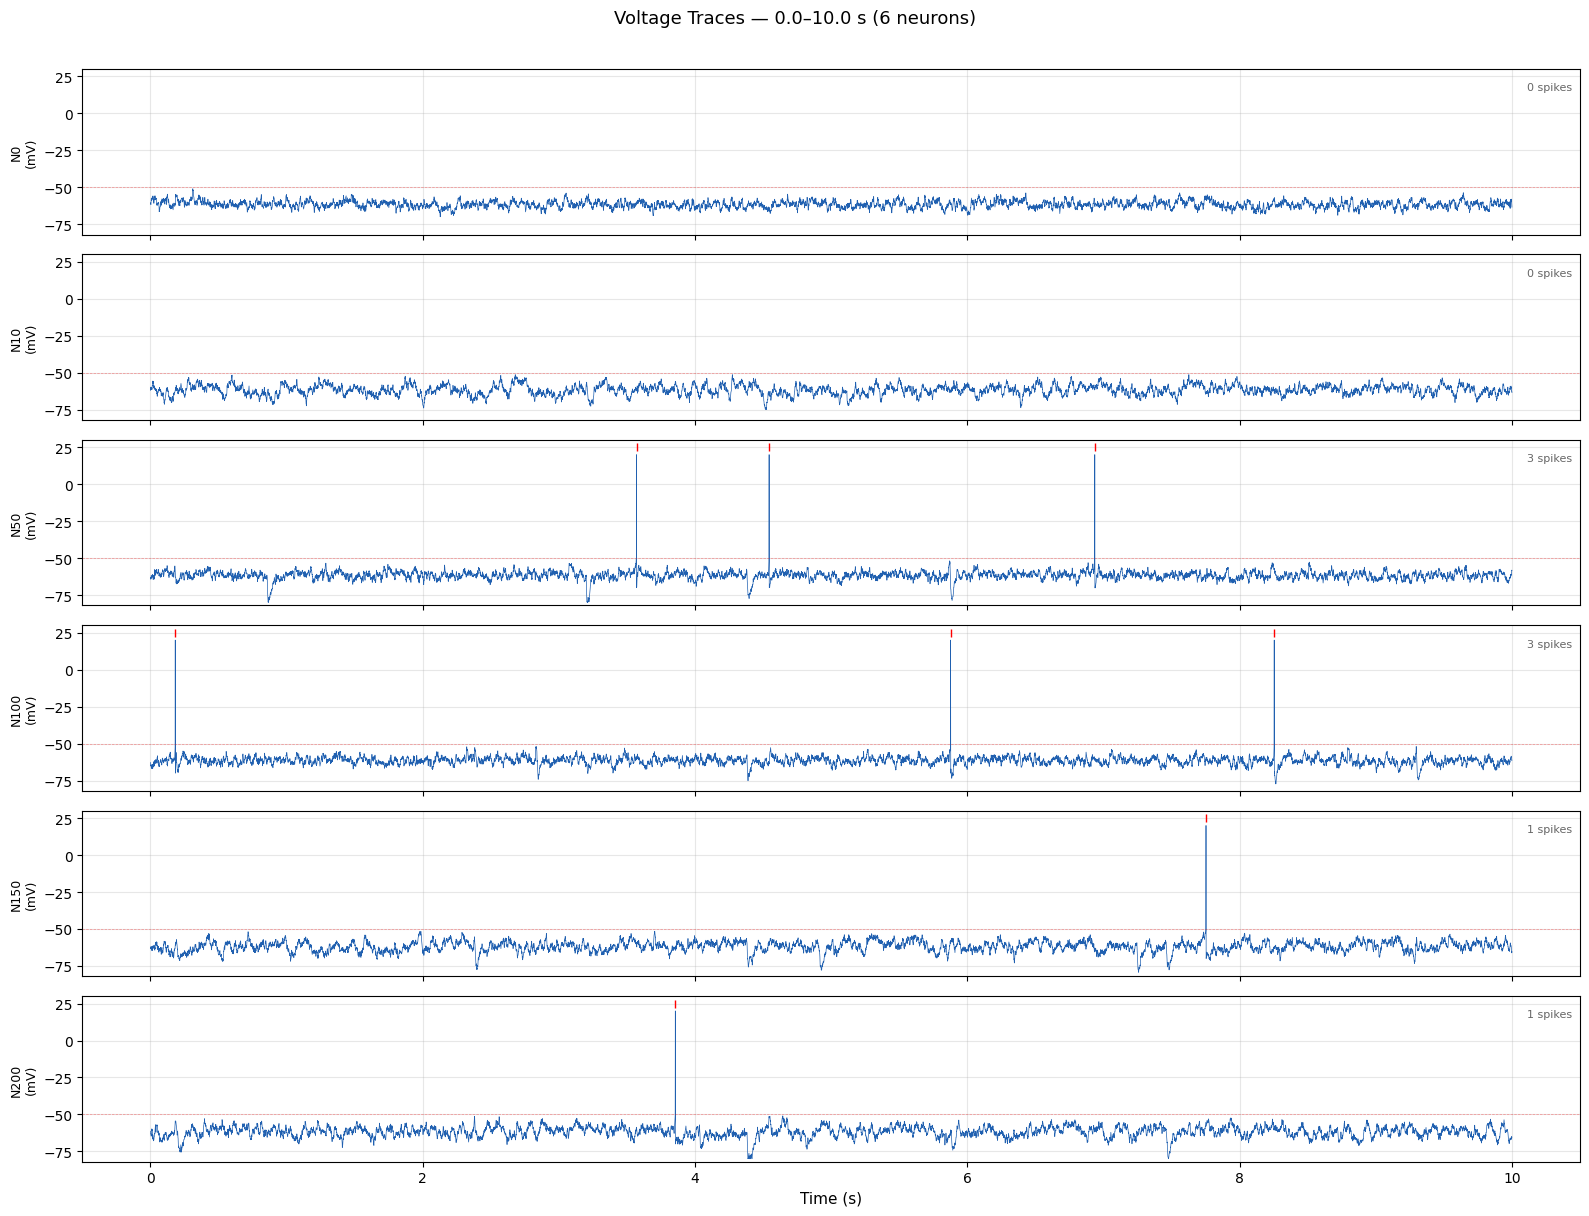

In [6]:
fig = plot_voltage_traces(
    voltage_traces, voltage_times, spike_times,
    neuron_ids=NEURON_IDS,
    time_window=TIME_WINDOW,
    fig_width=FIG_WIDTH,
    trace_height=TRACE_HEIGHT,
    show_threshold=SHOW_THRESHOLD,
    show_grid=SHOW_GRID,
)
plt.show()

## Quick-Access Examples

Uncomment and run any cell below for common views.

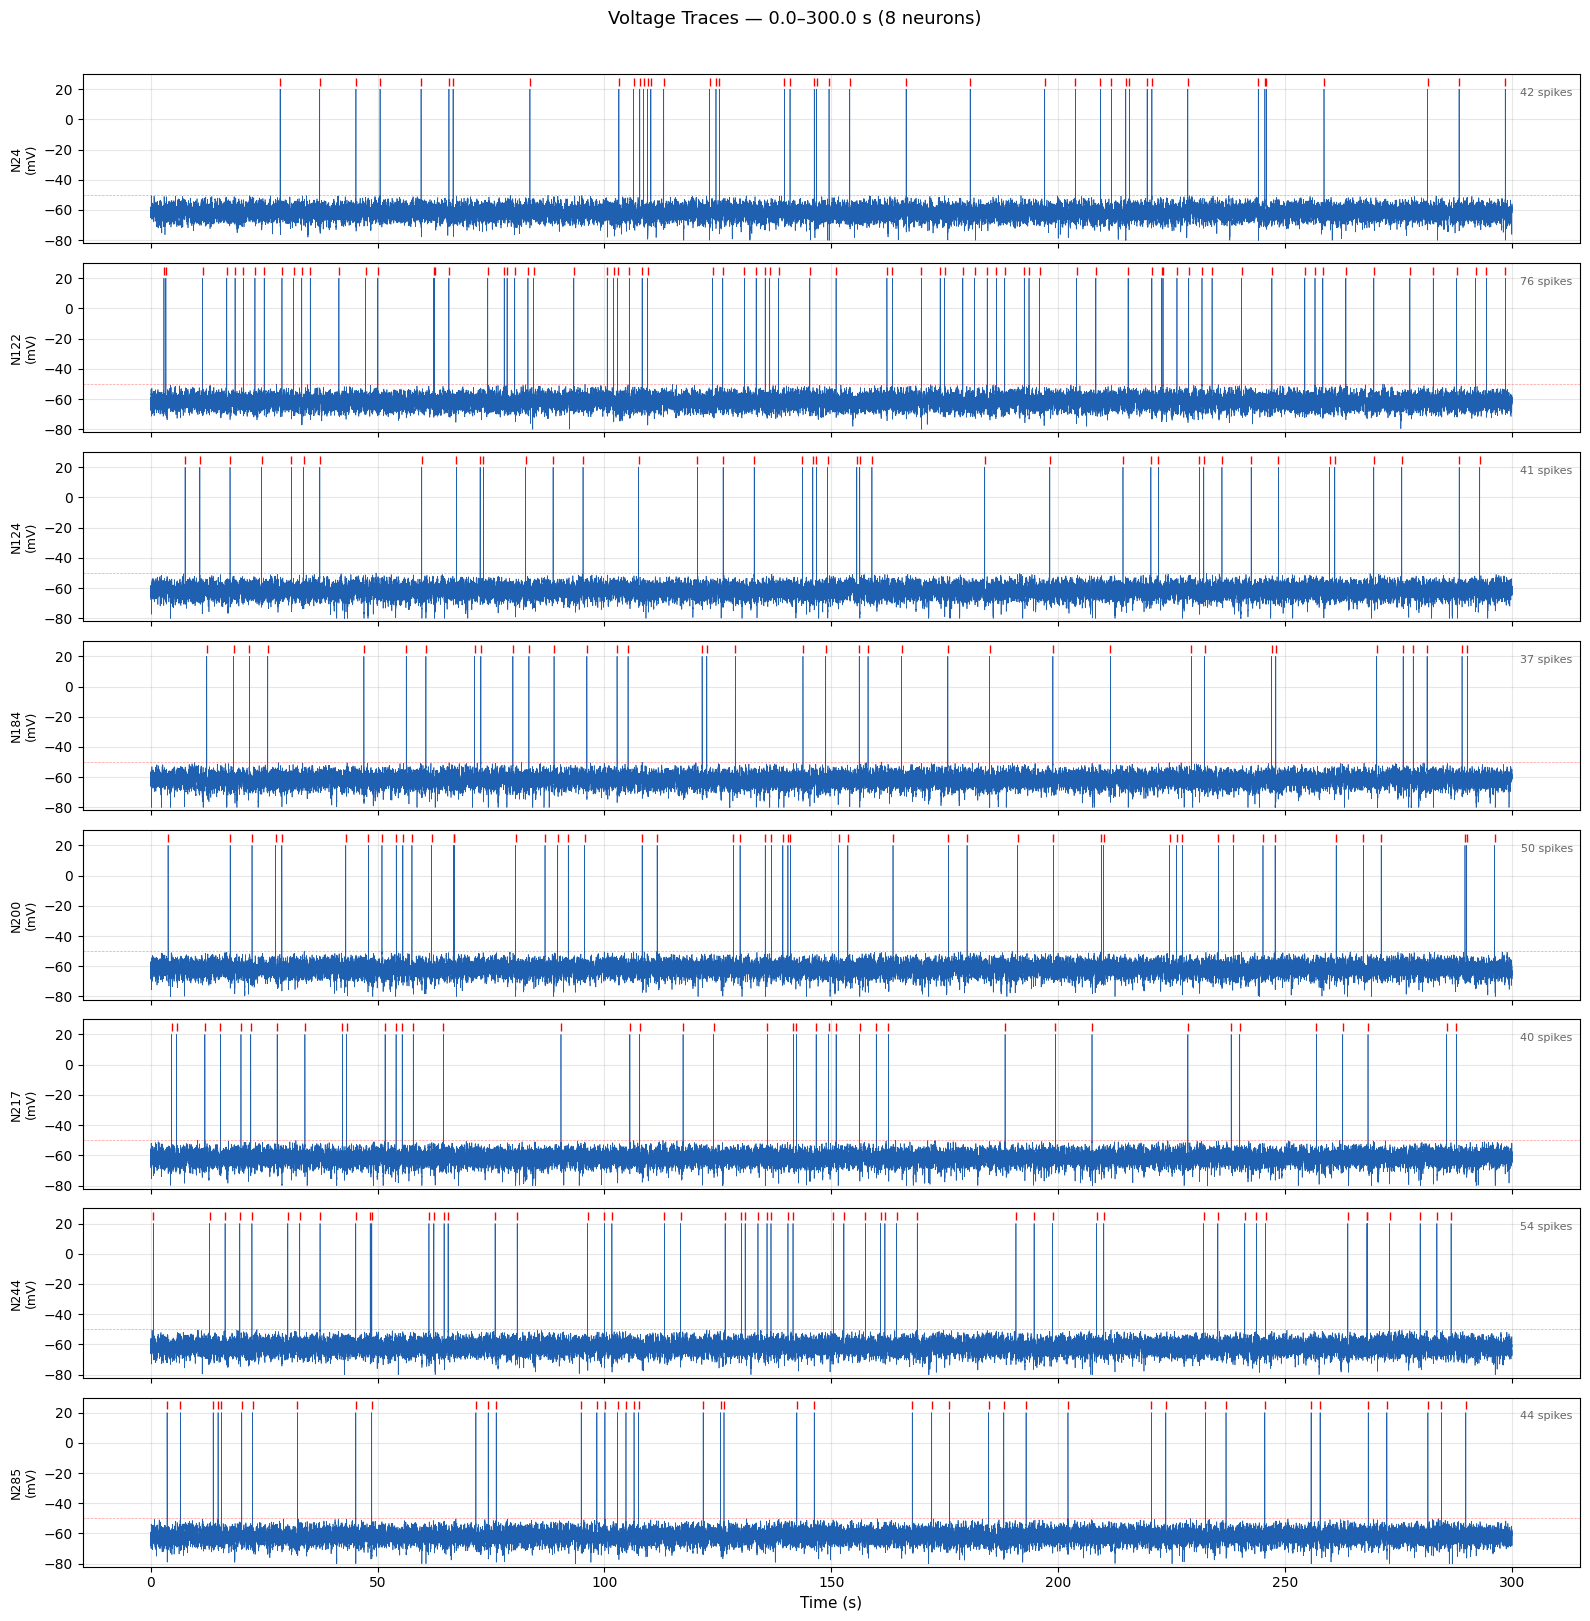

In [11]:
# Example 1: Random selection of 8 neurons, full duration
rng = np.random.default_rng(42)
random_ids = sorted(rng.choice(n_neurons, size=8, replace=False).tolist())
fig = plot_voltage_traces(voltage_traces, voltage_times, spike_times,
                          neuron_ids=random_ids, time_window=None)
plt.show()

In [8]:
# Example 2: Top-N most active neurons in a time window
# t0, t1 = 5000, 15000
# n_top = 6
# spike_counts = np.array([
#     np.sum((spike_times[i] >= t0) & (spike_times[i] <= t1))
#     if len(spike_times[i]) > 0 else 0
#     for i in range(n_neurons)
# ])
# top_ids = np.argsort(spike_counts)[-n_top:][::-1].tolist()
# print(f"Most active neurons in {t0/1000:.0f}-{t1/1000:.0f}s: {top_ids}")
# print(f"Spike counts: {spike_counts[top_ids]}")
# fig = plot_voltage_traces(voltage_traces, voltage_times, spike_times,
#                           neuron_ids=top_ids, time_window=(t0, t1))
# plt.show()

In [9]:
# Example 3: Zoom into a single neuron
# fig = plot_voltage_traces(voltage_traces, voltage_times, spike_times,
#                           neuron_ids=[42], time_window=(0, 5000),
#                           trace_height=3.0)
# plt.show()